# K-Nearest Neighbors (KNN)

## What Is KNN?

KNN embodies the simplest possible learning hypothesis: **similar inputs have similar outputs**. Given a new example, find the K training examples most similar to it (its *neighbors*) and let them vote on the answer.

There is no explicit training, no parameters to optimize, no gradient to compute. KNN memorizes the training data and reasons at prediction time. This makes it a **lazy learner**.

## 1. Setup & Data Download

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import urllib.request, os, sys

sys.path.insert(0, os.path.abspath('../../../src'))
from mlpackage.supervised_learning.knn import KNN
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report

CSV_PATH = 'penguins.csv'
if not os.path.exists(CSV_PATH):
    url = 'https://raw.githubusercontent.com/mwaskom/seaborn-data/master/penguins.csv'
    urllib.request.urlretrieve(url, CSV_PATH)
    print('Dataset downloaded.')
else:
    print('Dataset already present.')

Dataset downloaded.


## 2. Data Exploration

In [2]:
df = pd.read_csv(CSV_PATH)
print('Shape:', df.shape)
print('\nMissing values:\n', df.isnull().sum())
print('\nSpecies distribution:\n', df['species'].value_counts())
df.head()

Shape: (344, 7)

Missing values:
 species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64

Species distribution:
 species
Adelie       152
Gentoo       124
Chinstrap     68
Name: count, dtype: int64


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE


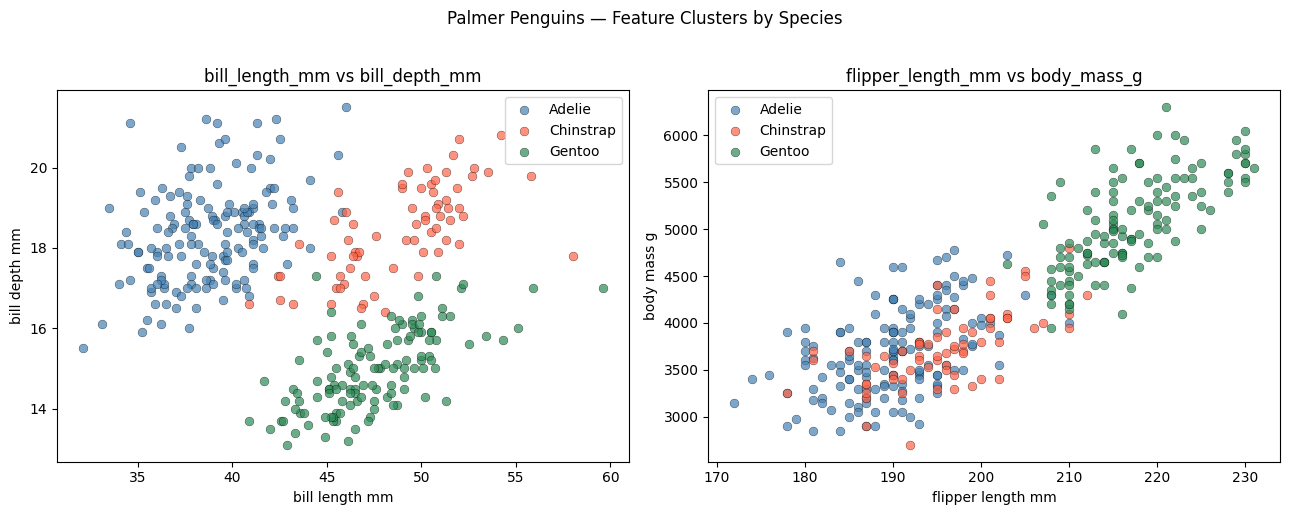

In [7]:
species_colors = {'Adelie': 'steelblue', 'Chinstrap': 'tomato', 'Gentoo': 'seagreen'}
feature_pairs = [
    ('bill_length_mm', 'bill_depth_mm'),
    ('flipper_length_mm', 'body_mass_g')
]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, (fx, fy) in zip(axes, feature_pairs):
    for species, color in species_colors.items():
        mask = df['species'] == species
        ax.scatter(df[mask][fx], df[mask][fy], label=species, color=color,
                   alpha=0.7, s=40, edgecolors='k', linewidths=0.3)
    ax.set_xlabel(fx.replace('_', ' '))
    ax.set_ylabel(fy.replace('_', ' '))
    ax.set_title(f'{fx} vs {fy}')
    ax.legend()

plt.suptitle('Palmer Penguins — Feature Clusters by Species', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

In these plots each dot is one penguin, colored by species.

Left plot — Bill dimensions: Chinstrap (red) overlaps slightly with Adelie (blue), but Gentoo (green) is clearly separate due to its long, narrow bill.

Right plot — Body size: Gentoo are much larger (heavier, longer flippers) and form a tight isolated cluster. Adelie and Chinstrap overlap more here.

A new penguin landing near the blue dots is almost certainly Adelie. This is exactly what KNN formalizes: classify by proximity to labeled examples in feature space.

## 3. Preprocessing

KNN computes distances, thus **scaling is mandatory**. `body_mass_g` ranges in the thousands while `bill_depth_mm` is in the tens. Without scaling, body mass would dominate every distance calculation and the other features would be ignored.

In [4]:
feature_cols = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']

# Drop rows with missing values (KNN cannot handle NaN)
df_clean = df[feature_cols + ['species']].dropna()
print(f'Samples after dropping NaN: {len(df_clean)} (removed {len(df) - len(df_clean)})')

le = LabelEncoder()
y = le.fit_transform(df_clean['species'])   # Adelie=0, Chinstrap=1, Gentoo=2
X = df_clean[feature_cols].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f'Train: {X_train_s.shape}  |  Test: {X_test_s.shape}')
print('Classes:', dict(zip(le.classes_, le.transform(le.classes_))))

Samples after dropping NaN: 342 (removed 2)
Train: (273, 4)  |  Test: (69, 4)
Classes: {'Adelie': np.int64(0), 'Chinstrap': np.int64(1), 'Gentoo': np.int64(2)}


## 4. Training with K = 5

In [5]:
model = KNN(k=5, task='classification', metric='euclidean')
model.fit(X_train_s, y_train)

print(f'Train accuracy : {model.score(X_train_s, y_train):.4f}')
print(f'Test  accuracy : {model.score(X_test_s, y_test):.4f}')

Train accuracy : 0.9890
Test  accuracy : 1.0000


## 5. Choosing K — Train vs Test Accuracy Curve

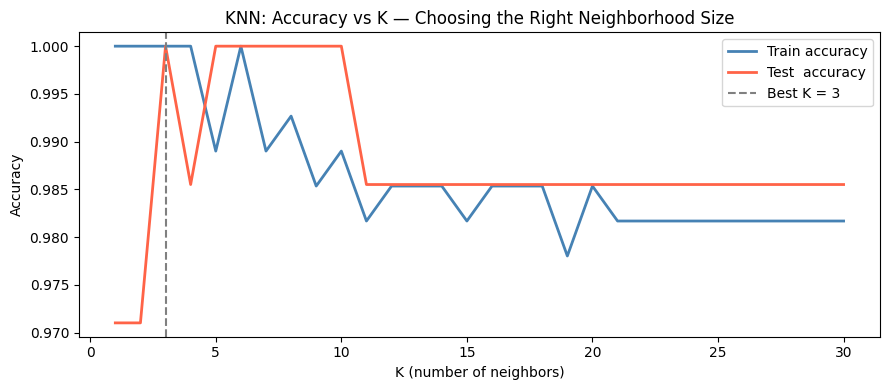

Best K on test set: 3  (accuracy = 1.0000)


In [8]:
k_range = range(1, 31)
train_accs, test_accs = [], []

for k in k_range:
    m = KNN(k=k).fit(X_train_s, y_train)
    train_accs.append(m.score(X_train_s, y_train))
    test_accs.append(m.score(X_test_s, y_test))

best_k = list(k_range)[np.argmax(test_accs)]

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(list(k_range), train_accs, label='Train accuracy', color='steelblue', linewidth=2)
ax.plot(list(k_range), test_accs,  label='Test  accuracy', color='tomato',    linewidth=2)
ax.axvline(best_k, color='gray', linestyle='--', label=f'Best K = {best_k}')
ax.set_xlabel('K (number of neighbors)')
ax.set_ylabel('Accuracy')
ax.set_title('KNN: Accuracy vs K — Choosing the Right Neighborhood Size')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Best K on test set: {best_k}  (accuracy = {max(test_accs):.4f})')

Blue line (train): At K=1, the model memorizes every training point perfectly and the train accuracy is 1.0. As K grows, train accuracy decreases because the model averages over more neighbors and cannot fit every training example.

Red line (test): Low K → overfitting (test accuracy below train accuracy). As K increases, test accuracy first rises (less overfitting) then falls
(underfitting: too many neighbors blurs the boundaries).

The gray dashed line marks the K that maximizes test accuracy. The gap between blue and red at K=1 is the classic overfitting signature.

This curve illustrates the bias-variance trade-off:
- K=1  → low bias, high variance (overfit)
- K=n  → high bias, low variance (underfit)
- K=optimal → the right balance

## 6. Decision Boundary Visualization

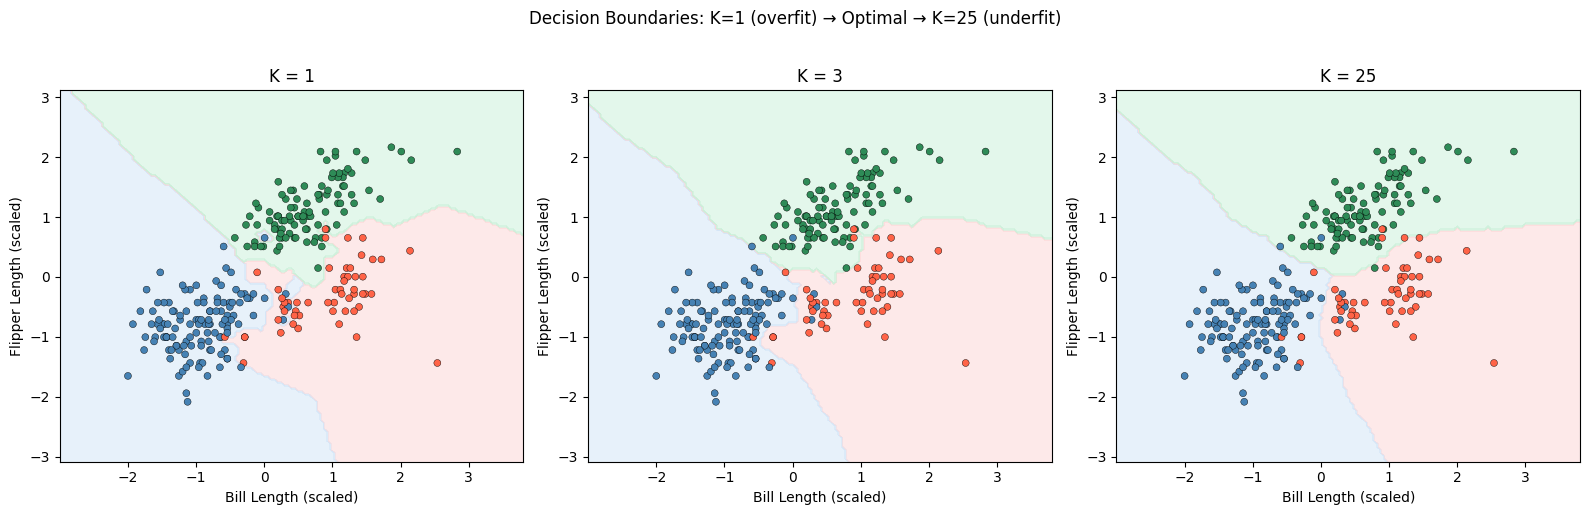

In [9]:
# Use bill length and flipper length (most discriminative)
f_idx = [0, 2]  # bill_length, flipper_length
X2_train = X_train_s[:, f_idx]
X2_test  = X_test_s[:, f_idx]

cmap_bg = ListedColormap(['#d0e4f7','#fdd5d5','#c8f0d8'])
cmap_pt = ListedColormap(['steelblue','tomato','seagreen'])

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, k in zip(axes, [1, best_k, 25]):
    m = KNN(k=k).fit(X2_train, y_train)

    h = 0.05
    x0_min, x0_max = X2_train[:,0].min()-1, X2_train[:,0].max()+1
    x1_min, x1_max = X2_train[:,1].min()-1, X2_train[:,1].max()+1
    xx, yy = np.meshgrid(np.arange(x0_min, x0_max, h),
                         np.arange(x1_min, x1_max, h))
    Z = m.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    ax.contourf(xx, yy, Z, cmap=cmap_bg, alpha=0.5)
    sc = ax.scatter(X2_train[:,0], X2_train[:,1], c=y_train,
                    cmap=cmap_pt, edgecolors='k', s=25, linewidths=0.3)
    ax.set_title(f'K = {k}', fontsize=12)
    ax.set_xlabel('Bill Length (scaled)')
    ax.set_ylabel('Flipper Length (scaled)')

plt.suptitle('Decision Boundaries: K=1 (overfit) → Optimal → K=25 (underfit)',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

Each background region shows which class KNN would predict for any point in that area. Dots are training samples colored by their true species.

K=1 (left): Every training point is its own decision region — the boundary is extremely jagged with small isolated islands. The model memorizes noise. Even a single mislabeled training point creates a misclassification island.

K=optimal (center): Smooth, coherent regions that follow the real cluster structure. The boundary generalizes well to unseen points.

K=25 (right): Over-smoothed — the model uses too large a neighborhood and some smaller clusters get absorbed into neighboring regions (underfitting).

The optimal K minimizes misclassification in the ambiguous boundary zones.

## 7. Distance Metric Comparison

In [10]:
metrics_results = {}
for metric in ['euclidean', 'manhattan', 'minkowski']:
    m = KNN(k=best_k, metric=metric).fit(X_train_s, y_train)
    metrics_results[metric] = m.score(X_test_s, y_test)
    print(f'{metric:12s}: {metrics_results[metric]:.4f}')

euclidean   : 1.0000
manhattan   : 0.9855
minkowski   : 1.0000


On well-scaled, continuous features like penguins', all three metrics tend to perform similarly. Large differences would signal that the feature space has a non-Euclidean structure (e.g., categorical variables, sparse data).

## 8. Evaluation

              precision    recall  f1-score   support

      Adelie       1.00      1.00      1.00        30
   Chinstrap       1.00      1.00      1.00        14
      Gentoo       1.00      1.00      1.00        25

    accuracy                           1.00        69
   macro avg       1.00      1.00      1.00        69
weighted avg       1.00      1.00      1.00        69



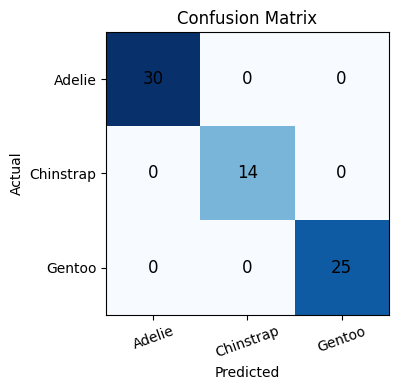

In [11]:
best_model = KNN(k=best_k).fit(X_train_s, y_train)
y_pred = best_model.predict(X_test_s)

print(classification_report(y_test, y_pred, target_names=le.classes_))

cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(5, 4))
ax.imshow(cm, cmap='Blues')
ax.set_xticks([0,1,2]); ax.set_xticklabels(le.classes_, rotation=20)
ax.set_yticks([0,1,2]); ax.set_yticklabels(le.classes_)
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
ax.set_title('Confusion Matrix')
for i in range(3):
    for j in range(3):
        ax.text(j, i, cm[i,j], ha='center', va='center', fontsize=12)
plt.tight_layout(); plt.show()

- Rows = actual species, Columns = predicted species.
- Diagonal cells (top-left to bottom-right) = correct predictions.
- Off-diagonal cells = errors. 

The confusion matrix shows that most errors occur between Adelie and Chinstrap, which overlap most in feature space; consistent with what the scatter plots showed. Gentoo is almost always classified correctly because it occupies a well-separated region (large body mass, long flippers).

## 9. Key Takeaways

- The **K vs accuracy curve** is the most important diagnostic for KNN: the peak of the test curve is the optimal K. The gap between train and test at K=1 measures overfitting severity.
- **Decision boundary plots** make the bias-variance trade-off concrete: K=1 is jagged (overfit), large K is blobby (underfit), optimal K is smooth.
- **Feature scaling is mandatory**. Without it, `body_mass_g` (in grams) would completely dominate `bill_depth_mm` (in millimeters) when computing Euclidean distance.
- KNN has **no training cost but high prediction cost**: O(n·d) per query, where n is training set size. It becomes impractical for very large datasets.
- Errors concentrate at class boundaries (Adelie/Chinstrap overlap), a fundamental property of any classifier, not a flaw.

## Why KNN?

KNN is fundamentally based on the intuition that *similar things tend to have similar labels*. Penguins make this intuition vivid:

- **Similarity has a clear biological meaning**. Two penguins with similar bill dimensions, flipper length, and body mass are likely the same species. KNN directly operationalizes this idea.
- **Three clearly separable clusters** make it easy to visualize how neighborhood voting works and what happens at the class boundaries.
- The dataset contains **missing values and categorical features**, giving us practice with real-world preprocessing that is always required before computing distances.